# Rabi result plots

Plots data collected by `rabi.py`'s `cmd_run()`. See `notes.md`'s "Rabi
oscillation (rabi.py)" section -- `rabi1`-`rabi9` are NOT reliable (taken
before the `anchor_free_reps`/trigger fixes for the background artifact)
-- `rabi_new` is the first run collected with those fixes applied.

## Load data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "D:/rabi"
FILE_NAMES = ["rabi_new", "rabi_new1", "rabi_new2_fix_trigger", "rabi_new3_fix_trigger", "rabi_new4_fix_trigger", "rabi_new5_fix_overload", "rabi_new6_fix_sensitivity", "rabi_new7_fix_sensitivity", "rabi_new8_fix_sensitivity", "rabi_new9_fix_sensitivity", "rabi_new10_fix_sensitivity", "rabi_new11_fix_anchor", "rabi_new12_fix_anchor", "rabi_new13_fix_anchor2", "rabi_new14_fix_anchor2", "rabi_new15_check_interlock", "rabi_new16_check_interlock", "rabi_new17_no_interlock", "rabi_new18_resets", "rabi_new19", "rabi_new20"]
GROUP_SIZE = 3  # runs per figure -- keeps each column wide enough to read as more runs pile up

runs = {}
for file_name in FILE_NAMES:
    run_path = f"{DATA_DIR}/{file_name}"

    mw_us = np.load(f"{run_path}/{file_name}_rabi_mw_us.npy")
    x_v = np.load(f"{run_path}/{file_name}_rabi_x.npy")
    y_v = np.load(f"{run_path}/{file_name}_rabi_y.npy")
    reflected_dbm = np.load(f"{run_path}/{file_name}_rabi_reflected_dbm.npy")

    with open(f"{run_path}/{file_name}_rabi_metadata.txt") as fh:
        metadata_text = fh.read()
    metadata = dict(
        (k, float(v)) for k, v in
        (line.split("=", 1) for line in metadata_text.strip().splitlines())
    )

    runs[file_name] = dict(
        run_path=run_path, mw_us=mw_us, x_v=x_v, y_v=y_v,
        reflected_dbm=reflected_dbm, metadata=metadata,
    )

    print(f"{file_name}: {len(mw_us)} points, tau_mw {mw_us.min():.3f}-{mw_us.max():.3f} us")
    print(metadata_text)


def chunked_runs():
    """Yield successive GROUP_SIZE-sized chunks of (file_name, d) pairs --
    one figure per chunk keeps columns readable instead of cramming every
    run collected so far into one increasingly-wide row."""
    items = list(runs.items())
    for start in range(0, len(items), GROUP_SIZE):
        yield items[start:start + GROUP_SIZE]


rabi_new: 101 points, tau_mw 0.020-10.020 us
freq_hz=2843000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=2e-05
phase_deg=0.0

rabi_new1: 50 points, tau_mw 0.020-1.000 us
freq_hz=2843000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=5e-05
phase_deg=0.0

rabi_new2_fix_trigger: 21 points, tau_mw 0.020-10.020 us
freq_hz=2844000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=2e-05
phase_deg=0.0

rabi_new3_fix_trigger: 21 points, tau_mw 0.020-1.020 us
freq_hz=2844000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0

rabi_new4_fix_trigger: 99 points, tau_mw 0.02

## Rabi X/Y/R, per run

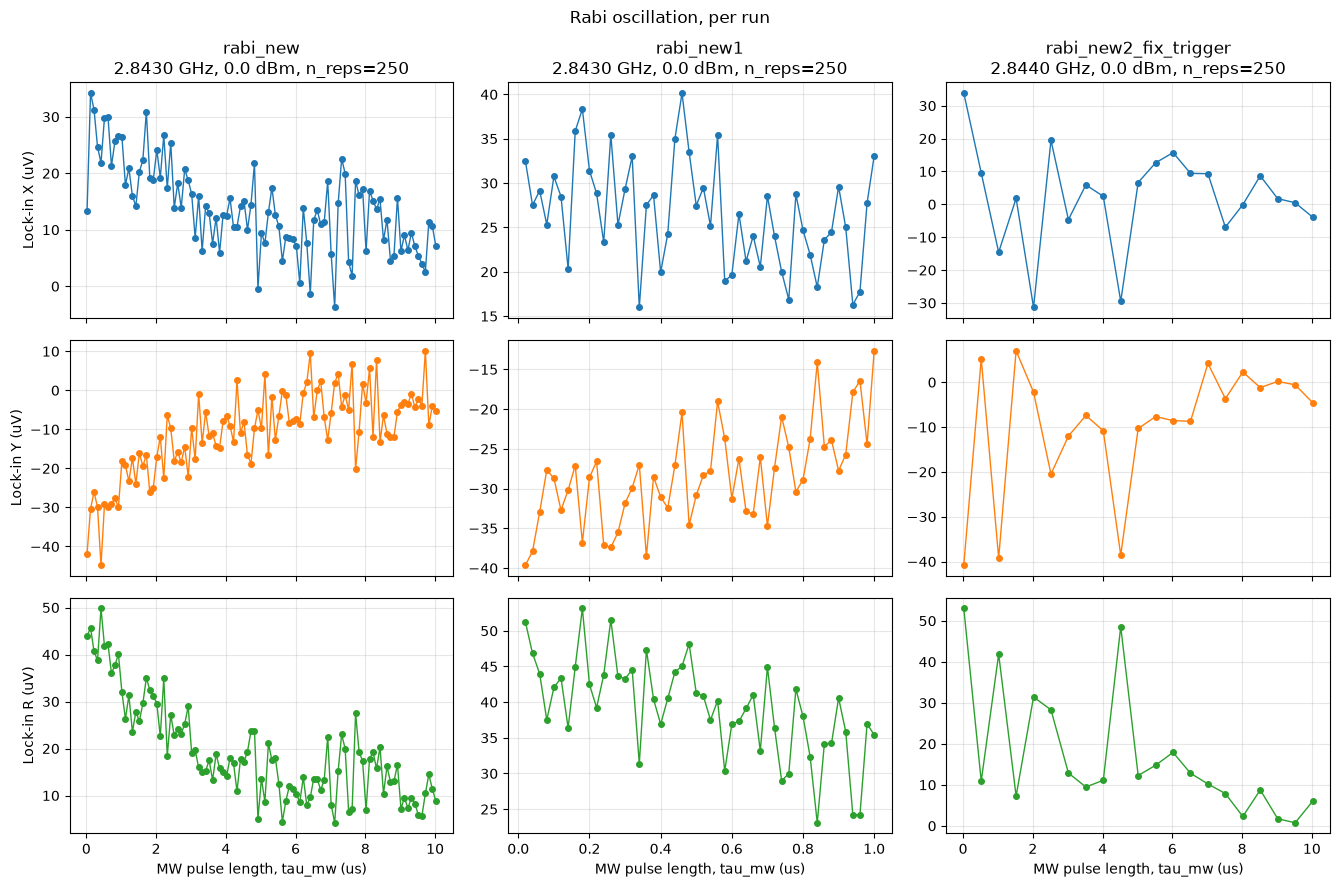

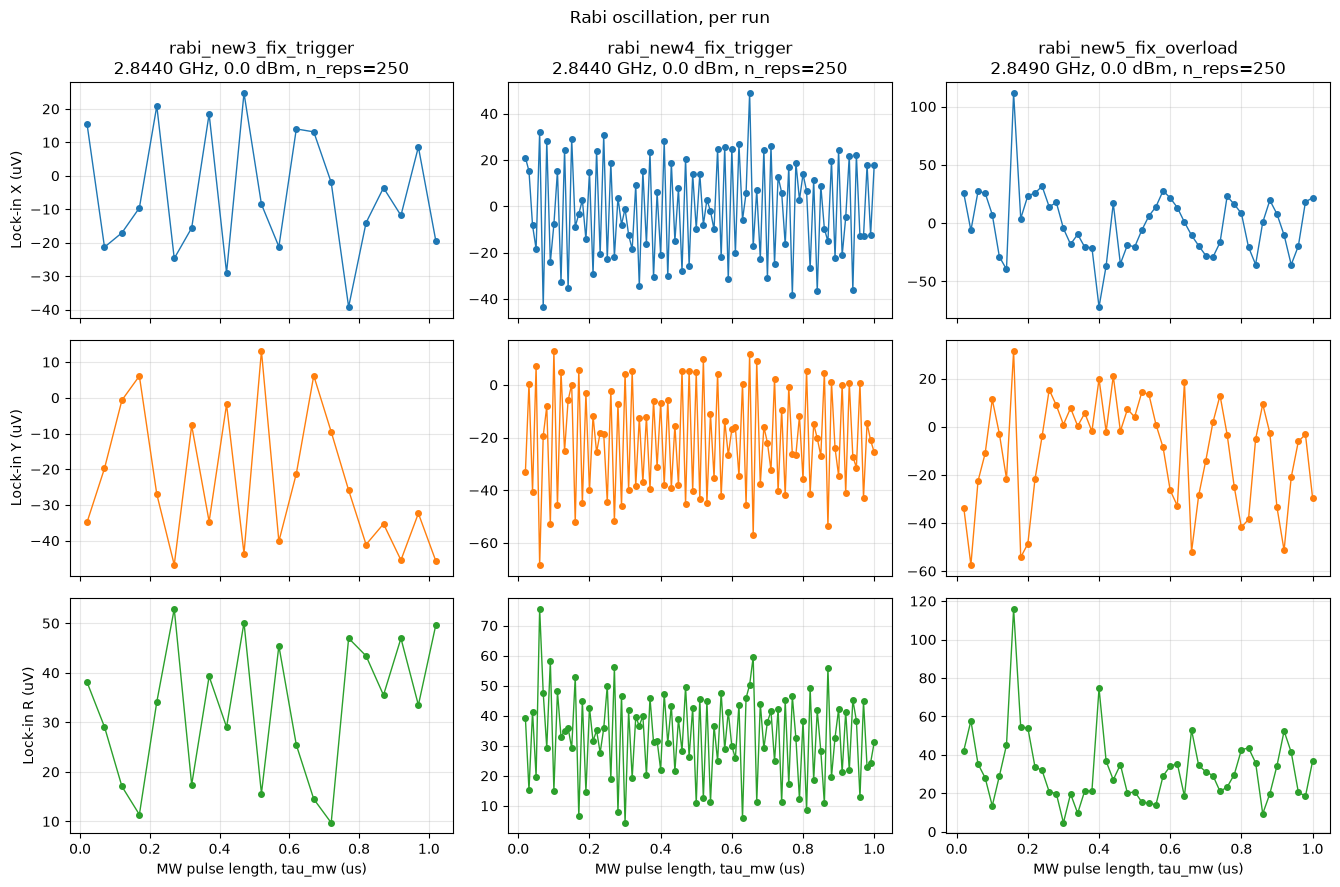

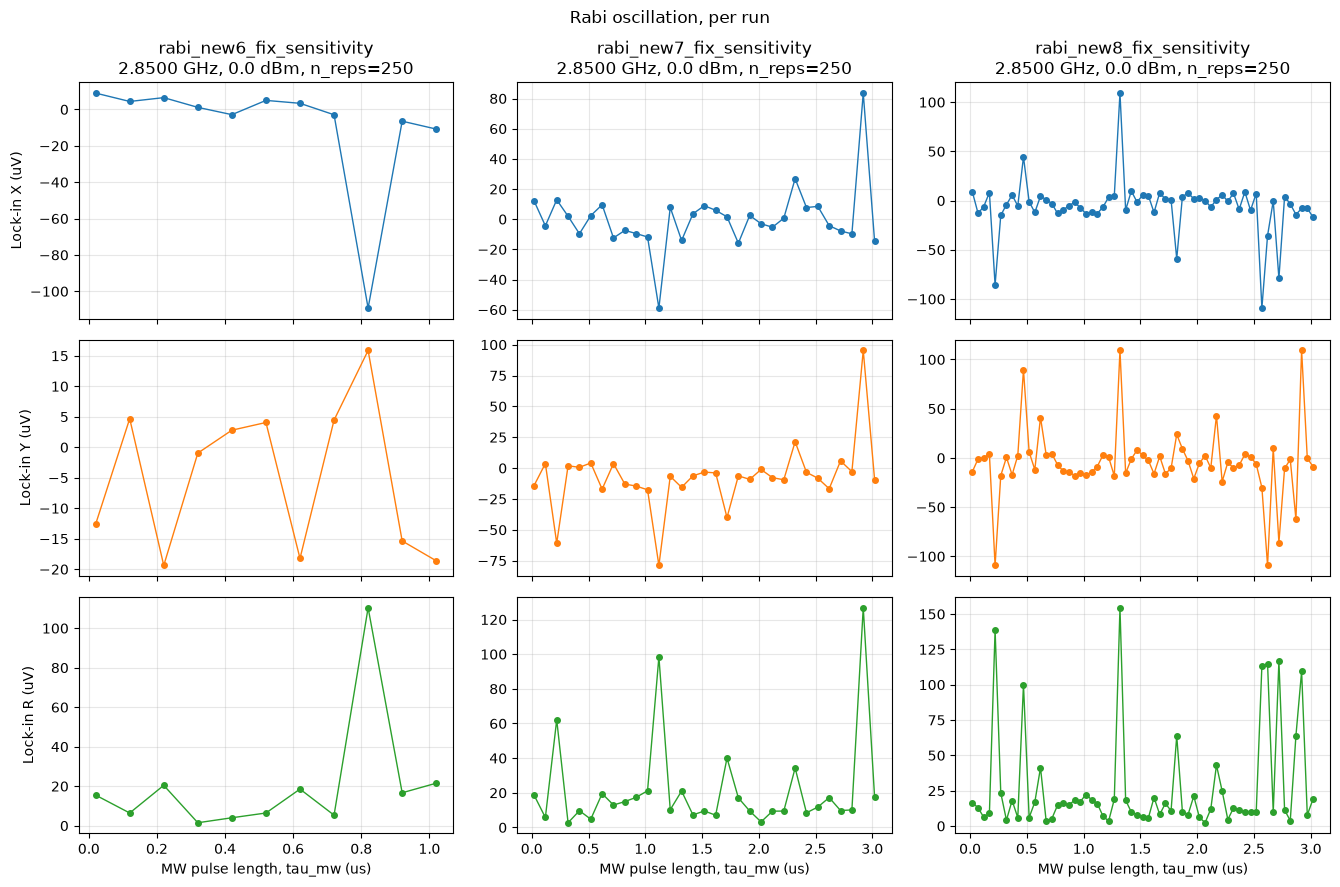

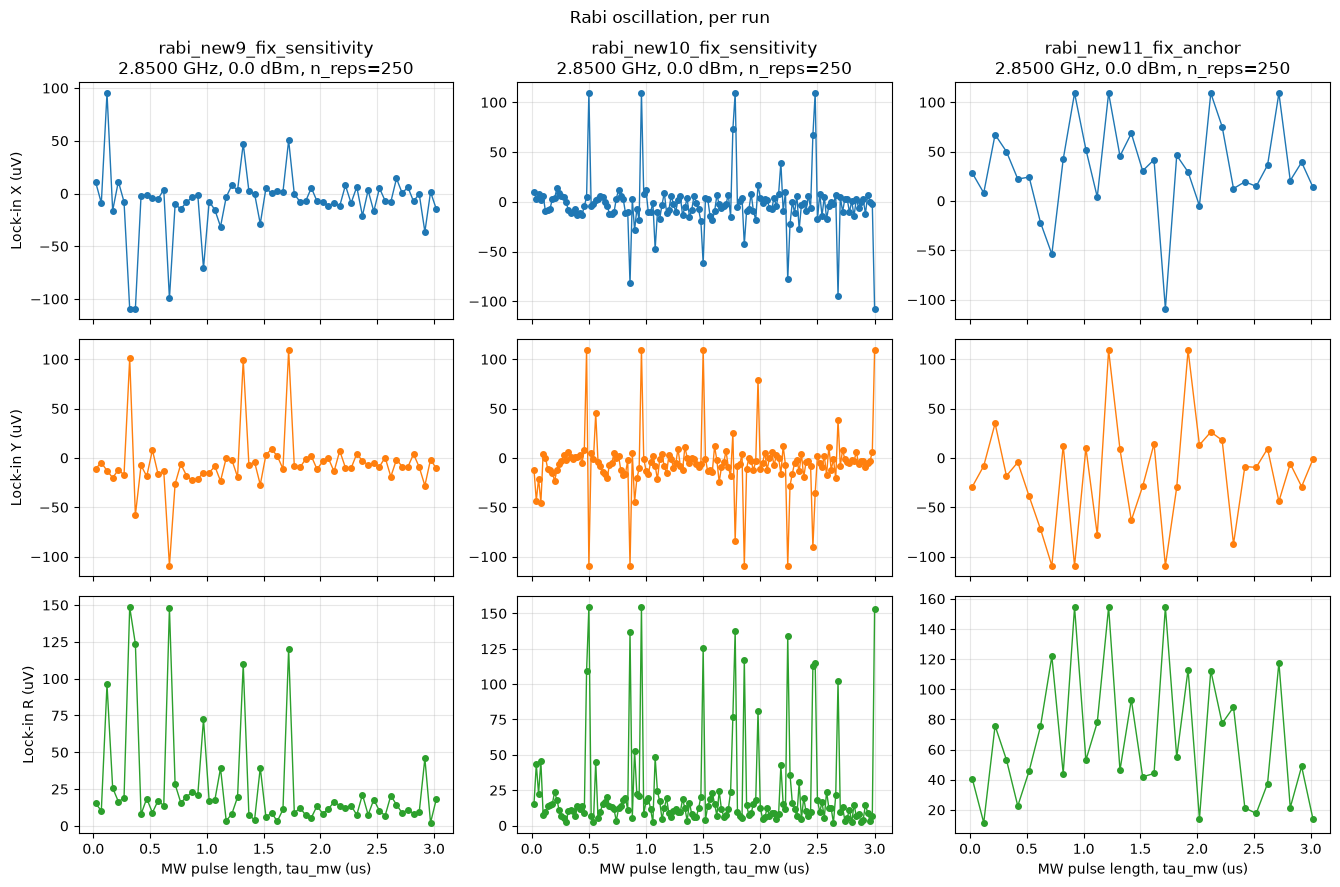

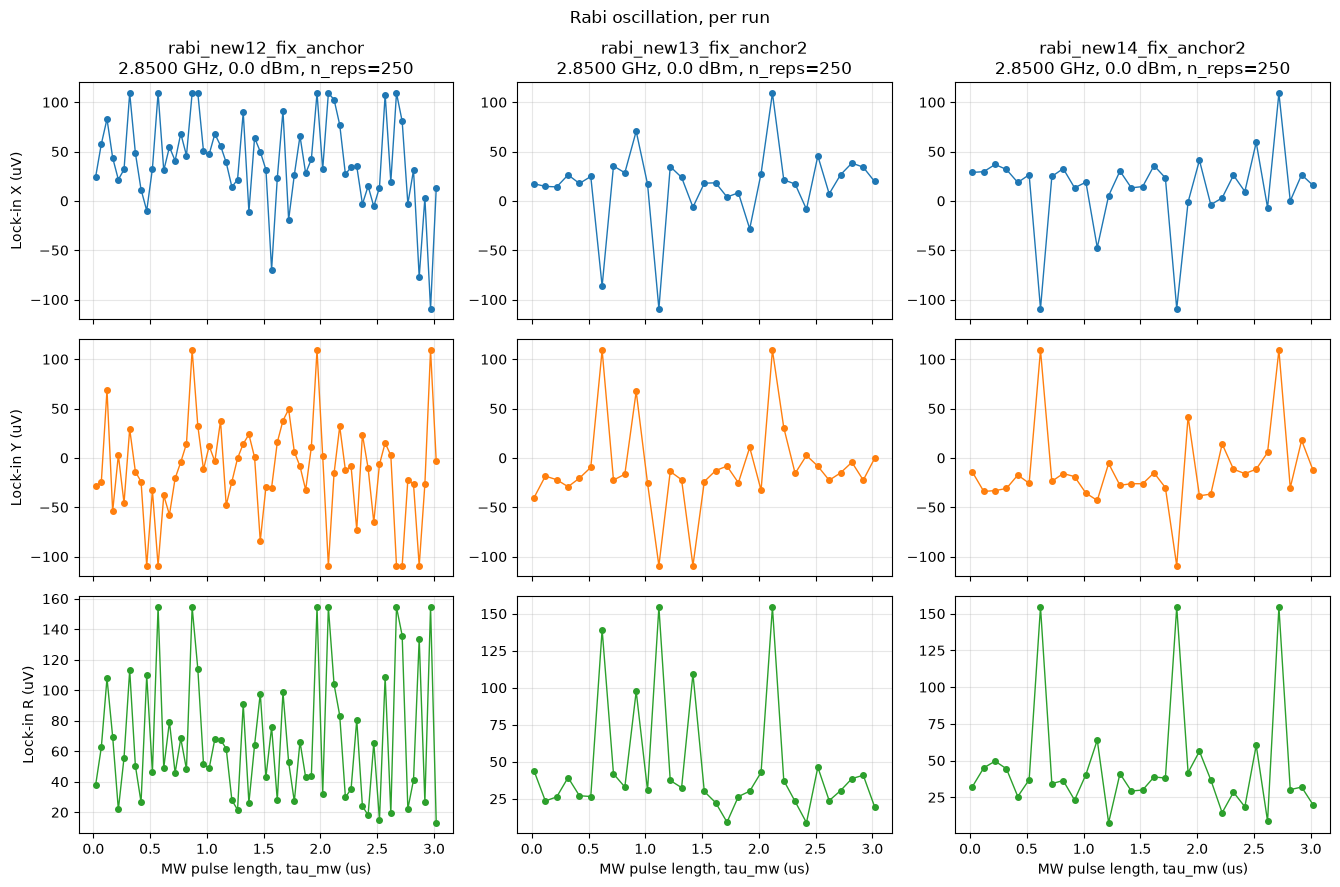

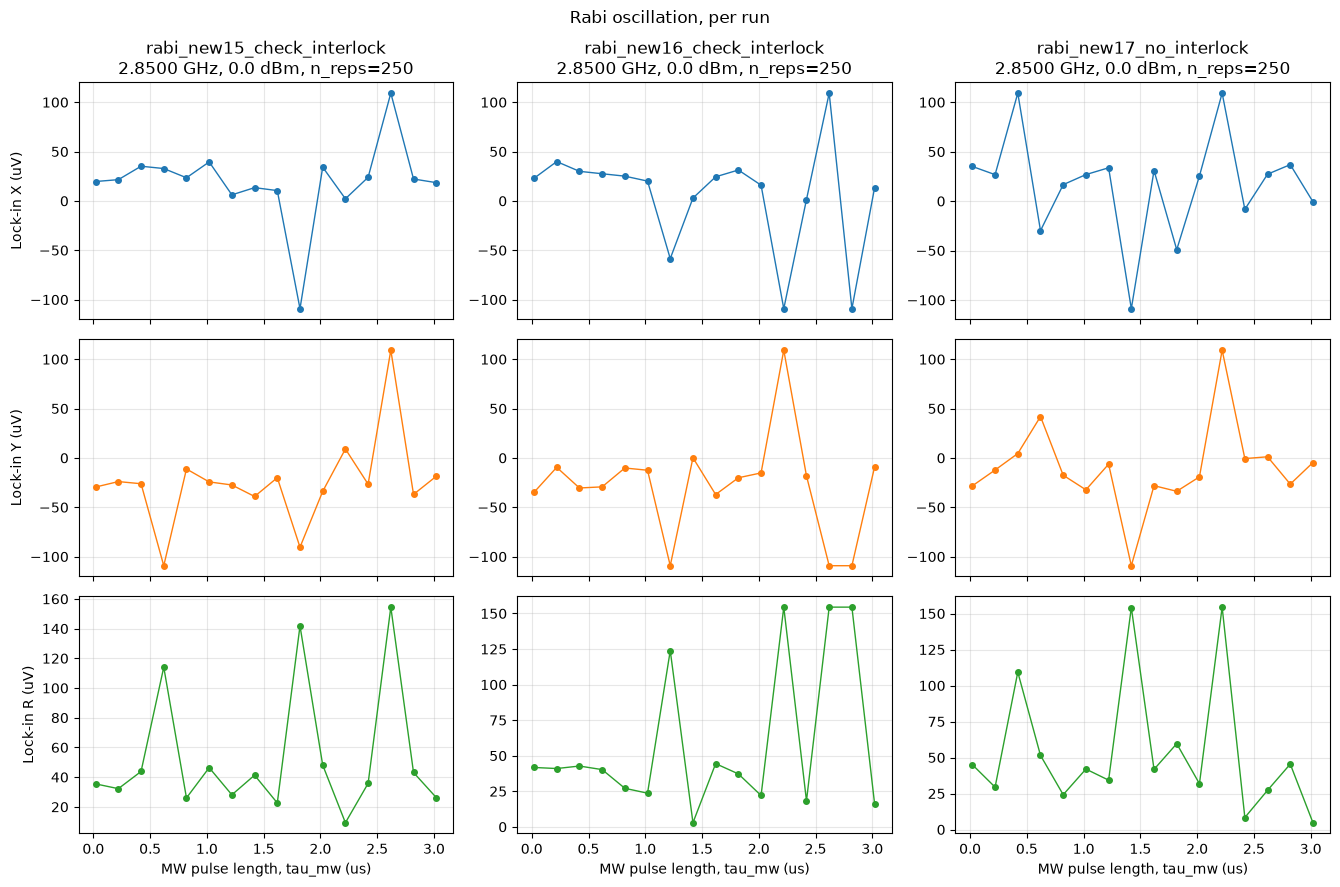

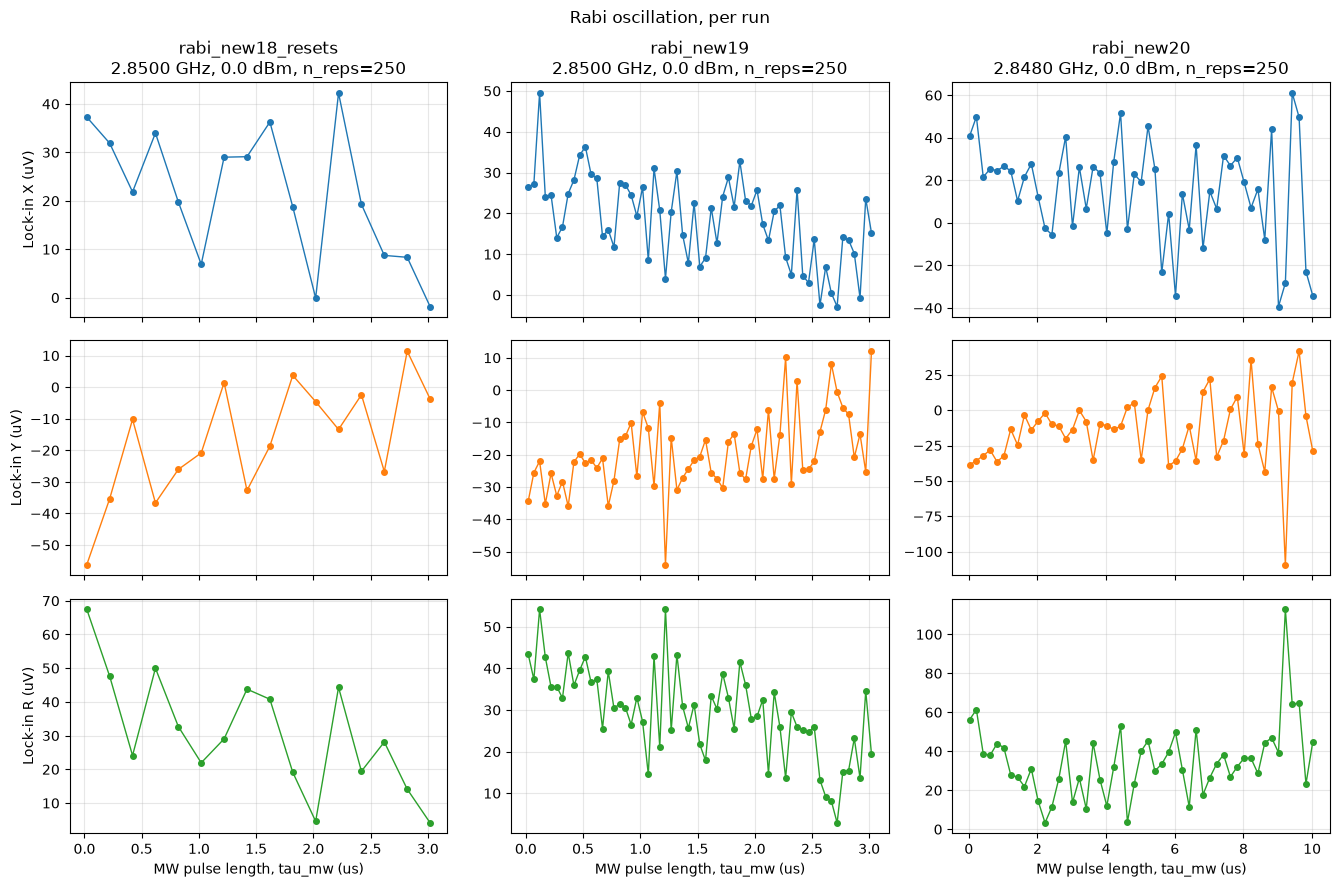

In [2]:
for group in chunked_runs():
    n_runs = len(group)
    fig, axes = plt.subplots(3, n_runs, figsize=(4.5 * n_runs, 9), sharex="col", squeeze=False)

    for col, (file_name, d) in enumerate(group):
        r_v = np.sqrt(d["x_v"]**2 + d["y_v"]**2)
        axes[0, col].plot(d["mw_us"], d["x_v"] * 1e6, "o-", ms=4, lw=1, color="tab:blue")
        axes[1, col].plot(d["mw_us"], d["y_v"] * 1e6, "o-", ms=4, lw=1, color="tab:orange")
        axes[2, col].plot(d["mw_us"], r_v * 1e6, "o-", ms=4, lw=1, color="tab:green")

        freq_ghz = d["metadata"]["freq_hz"] / 1e9
        drive_dbm = d["metadata"]["drive_power_dbm"]
        n_reps = int(d["metadata"]["n_reps"])
        axes[0, col].set_title(f"{file_name}\n{freq_ghz:.4f} GHz, {drive_dbm:.1f} dBm, n_reps={n_reps}")

        axes[2, col].set_xlabel("MW pulse length, tau_mw (us)")
        for row in range(3):
            axes[row, col].grid(alpha=0.3)

    axes[0, 0].set_ylabel("Lock-in X (uV)")
    axes[1, 0].set_ylabel("Lock-in Y (uV)")
    axes[2, 0].set_ylabel("Lock-in R (uV)")

    fig.suptitle("Rabi oscillation, per run")
    plt.tight_layout()
    plt.show()


## Same Rabi data, scatter only (no connecting line)

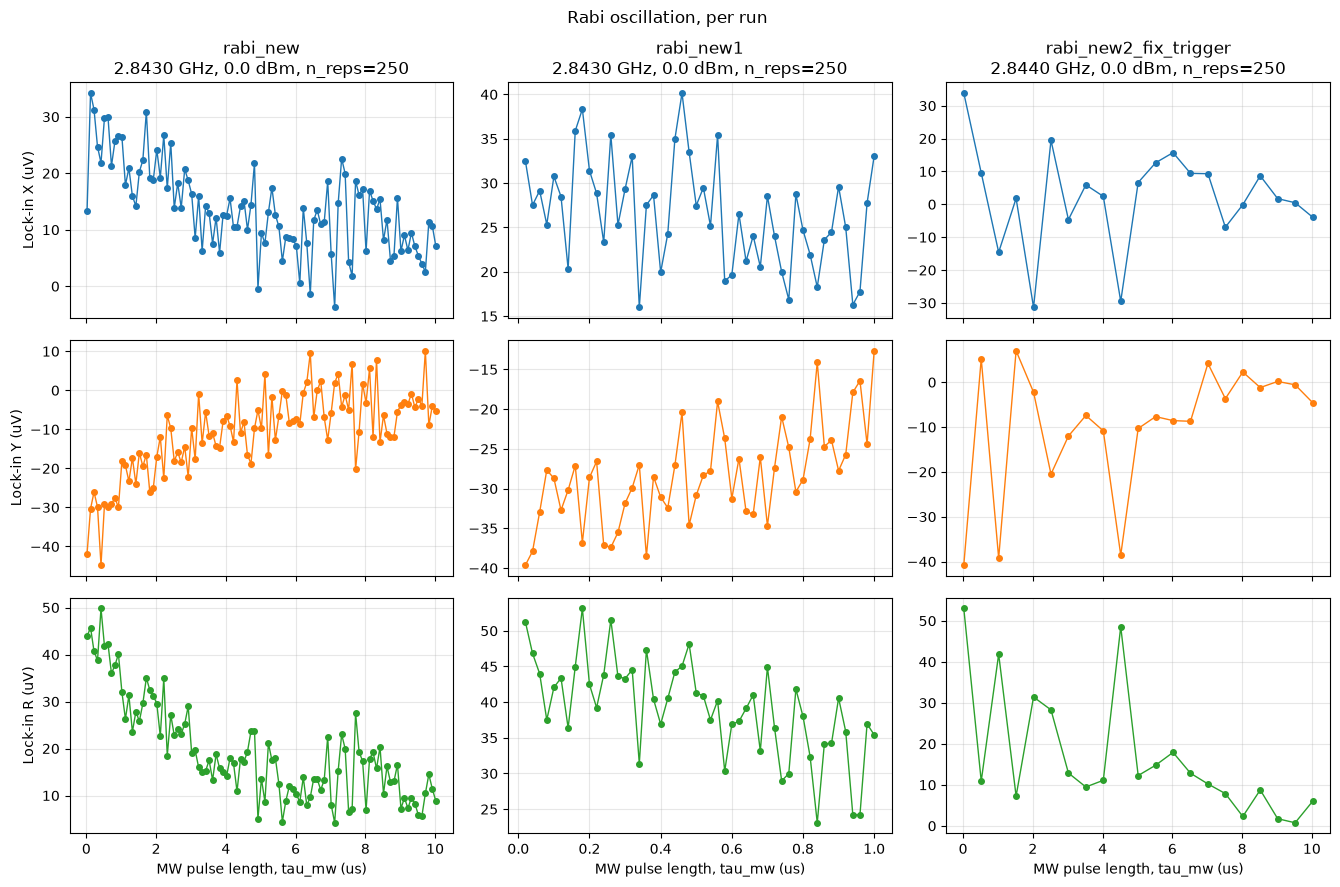

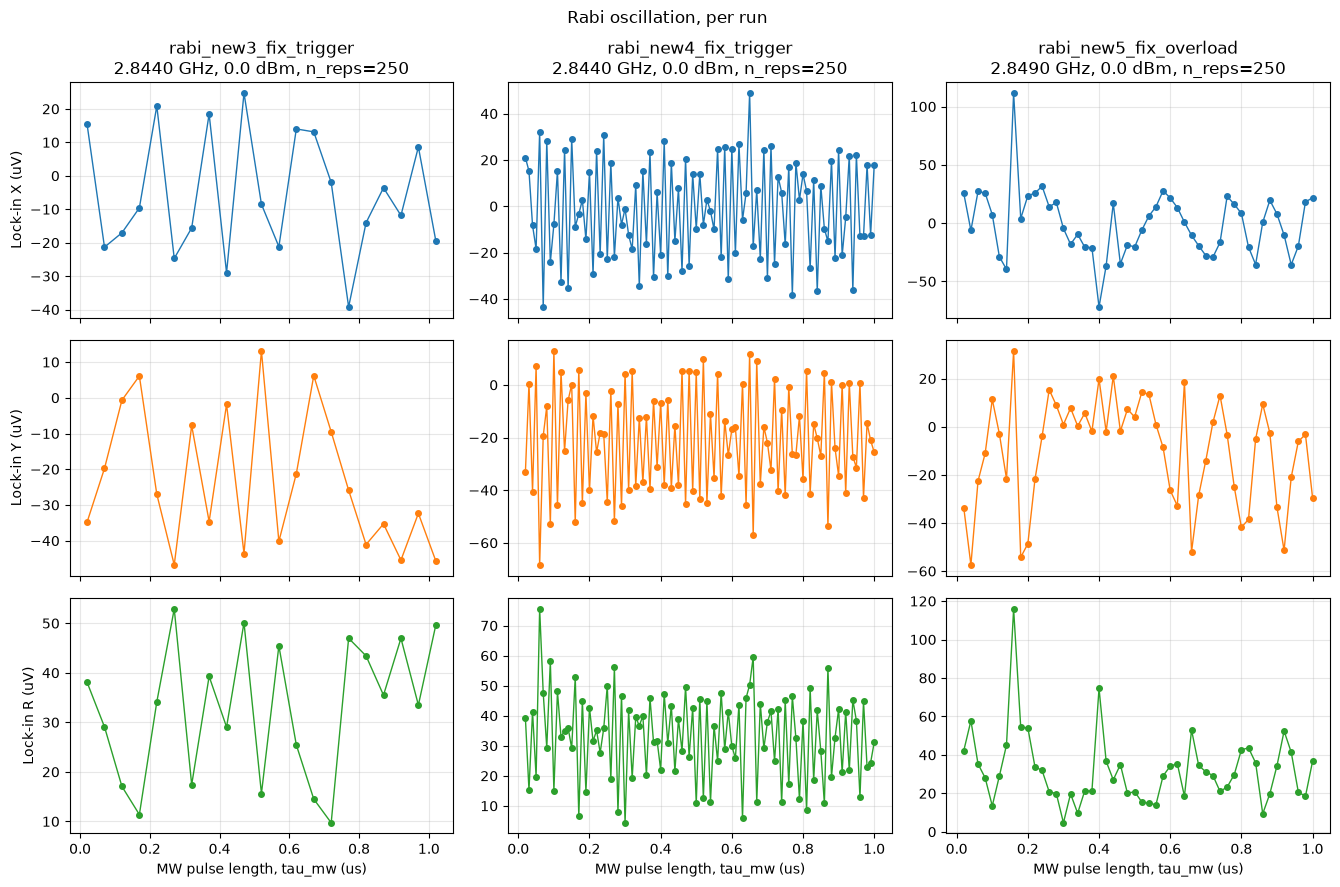

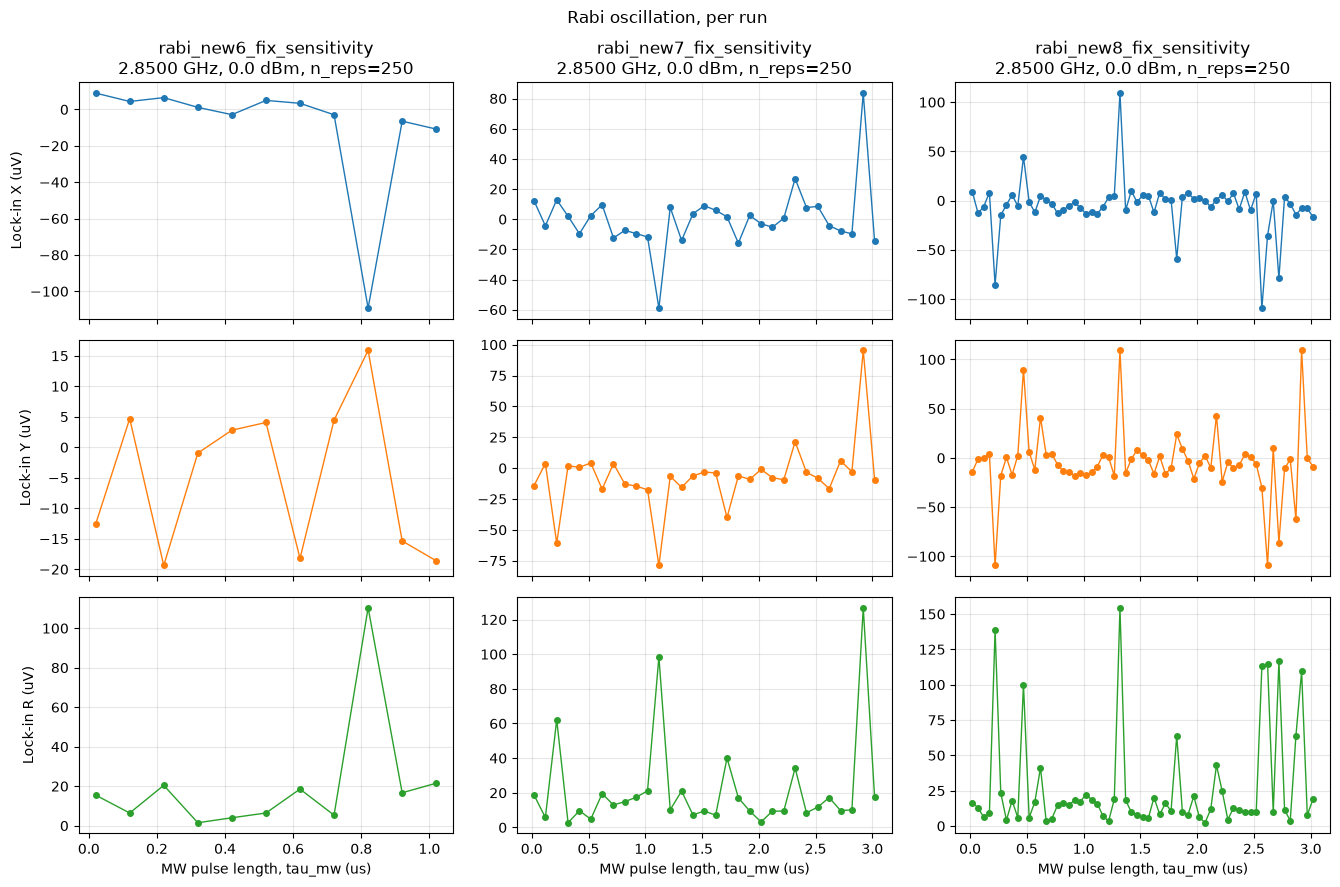

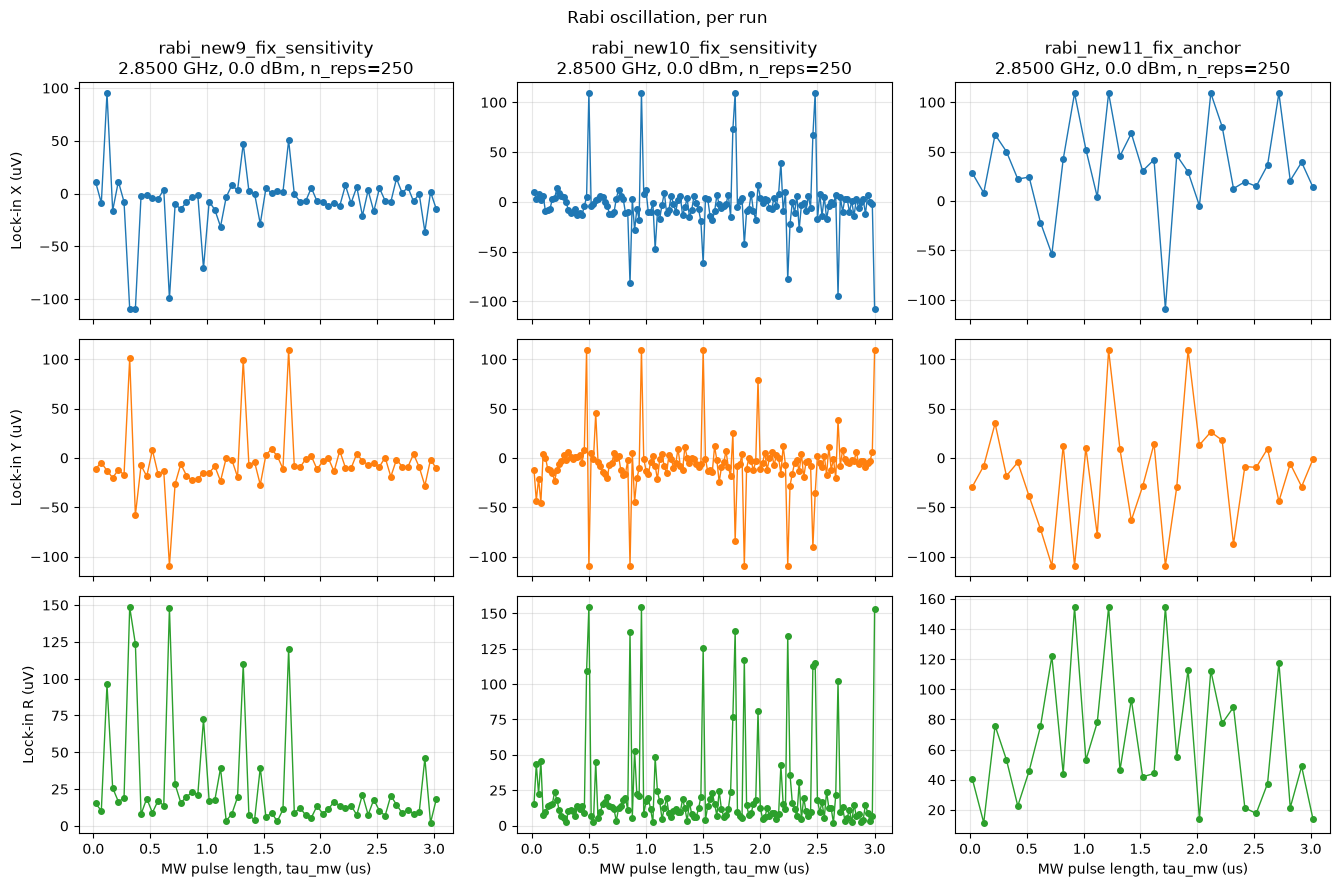

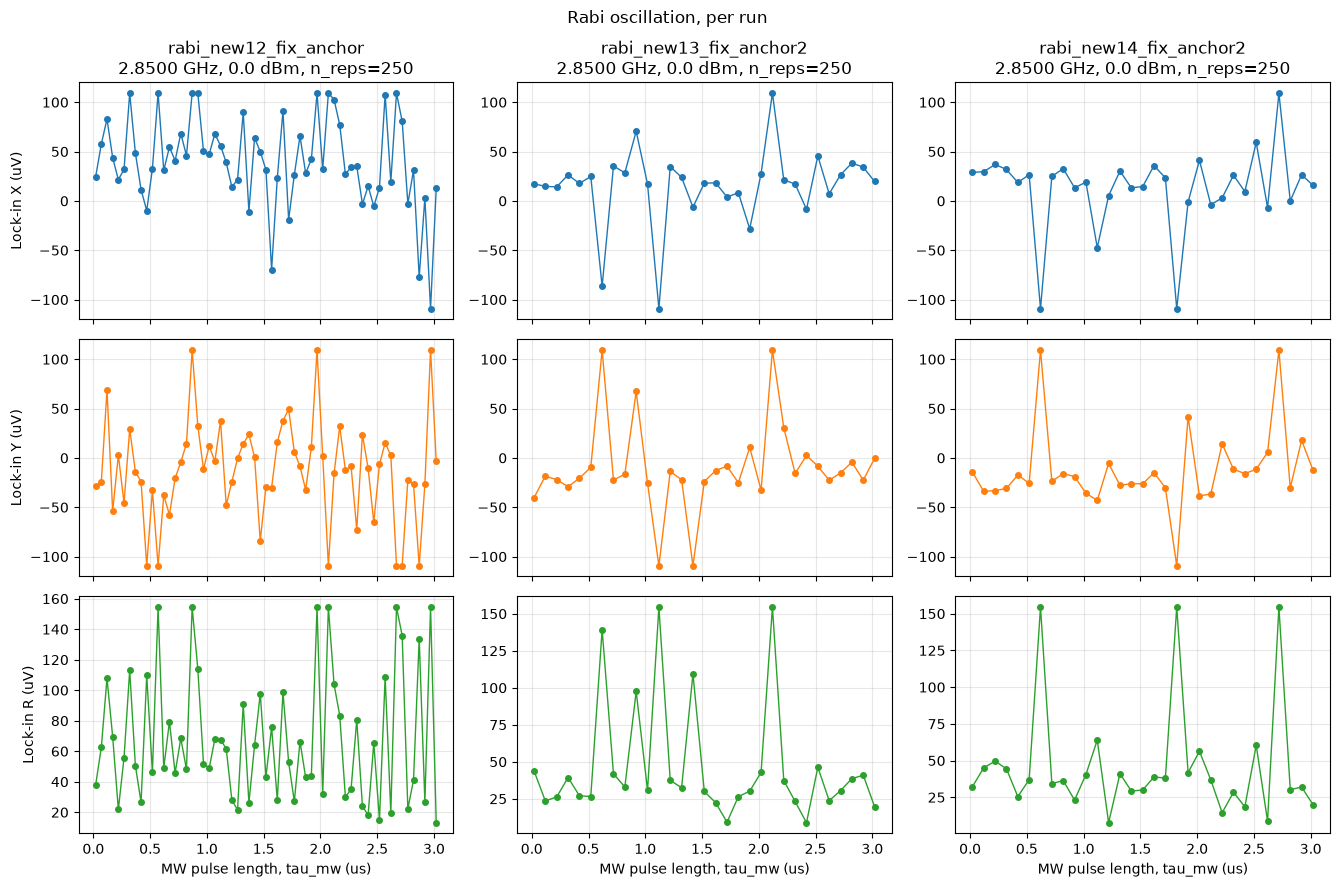

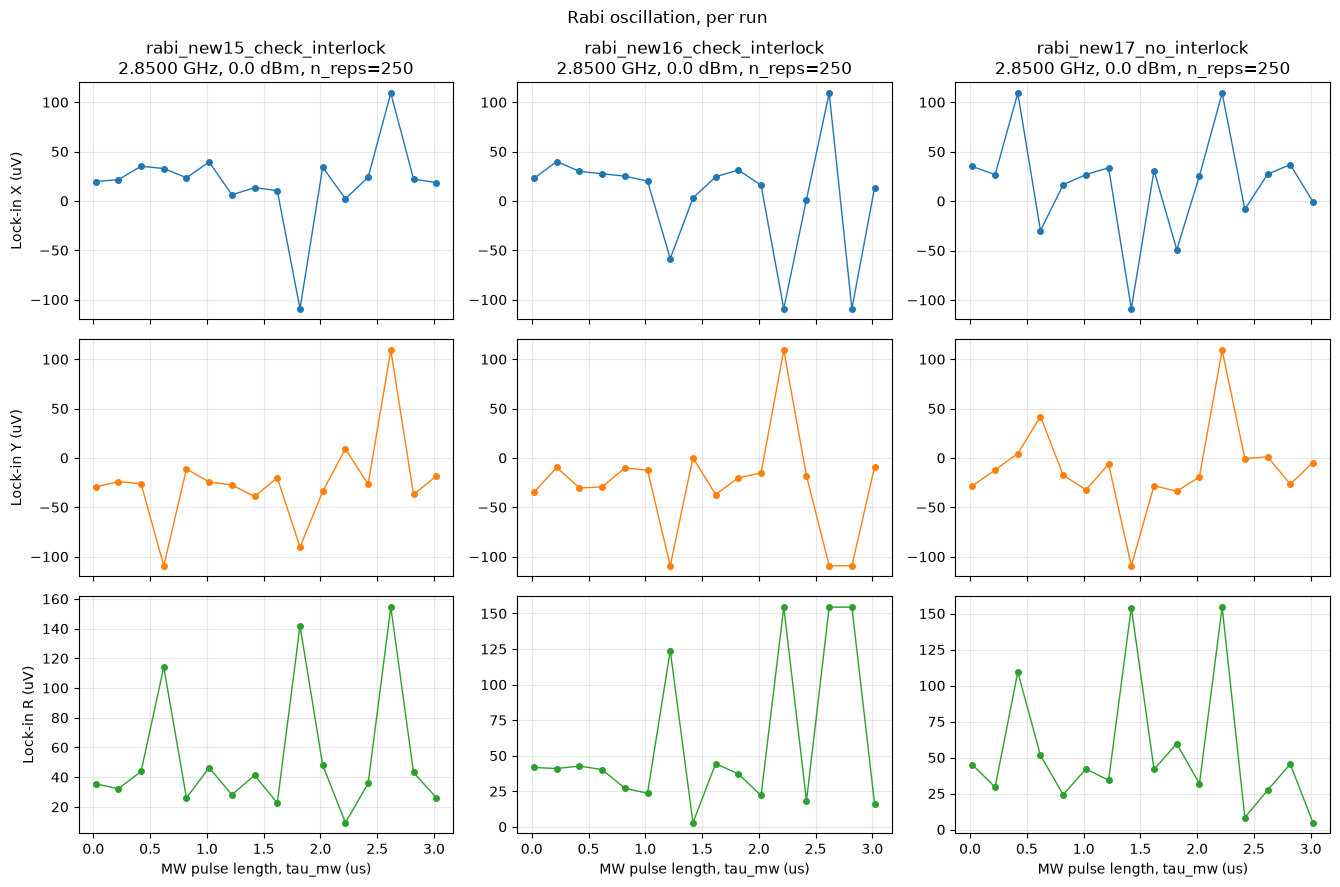

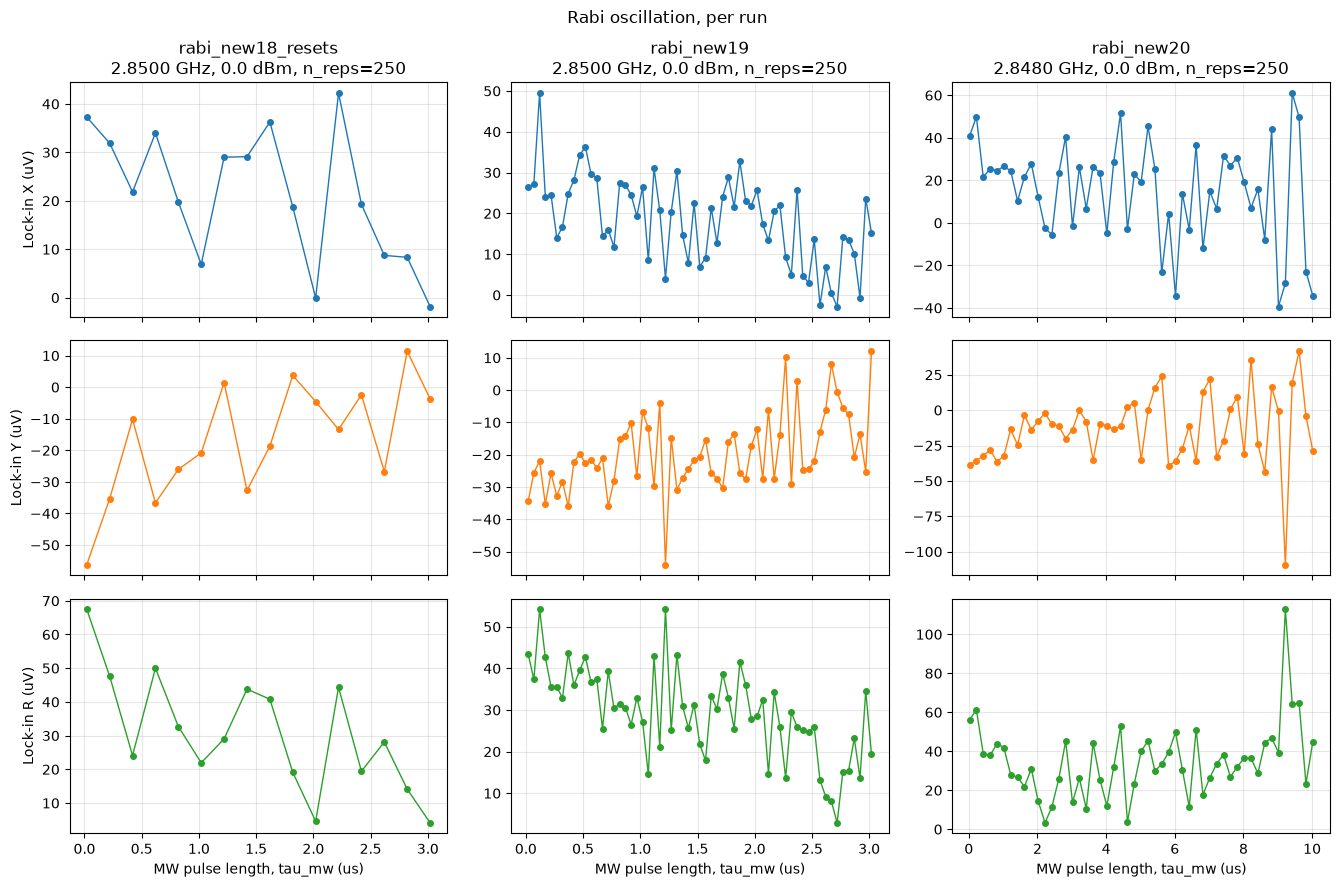

In [3]:
for group in chunked_runs():
    n_runs = len(group)
    fig, axes = plt.subplots(3, n_runs, figsize=(4.5 * n_runs, 9), sharex="col", squeeze=False)

    for col, (file_name, d) in enumerate(group):
        r_v = np.sqrt(d["x_v"]**2 + d["y_v"]**2)
        axes[0, col].plot(d["mw_us"], d["x_v"] * 1e6, "o-", ms=4, lw=1, color="tab:blue")
        axes[1, col].plot(d["mw_us"], d["y_v"] * 1e6, "o-", ms=4, lw=1, color="tab:orange")
        axes[2, col].plot(d["mw_us"], r_v * 1e6, "o-", ms=4, lw=1, color="tab:green")

        freq_ghz = d["metadata"]["freq_hz"] / 1e9
        drive_dbm = d["metadata"]["drive_power_dbm"]
        n_reps = int(d["metadata"]["n_reps"])
        axes[0, col].set_title(f"{file_name}\n{freq_ghz:.4f} GHz, {drive_dbm:.1f} dBm, n_reps={n_reps}")

        axes[2, col].set_xlabel("MW pulse length, tau_mw (us)")
        for row in range(3):
            axes[row, col].grid(alpha=0.3)

    axes[0, 0].set_ylabel("Lock-in X (uV)")
    axes[1, 0].set_ylabel("Lock-in Y (uV)")
    axes[2, 0].set_ylabel("Lock-in R (uV)")

    fig.suptitle("Rabi oscillation, per run ")
    plt.tight_layout()
    plt.show()


## Interlock reflected-power checks, per run

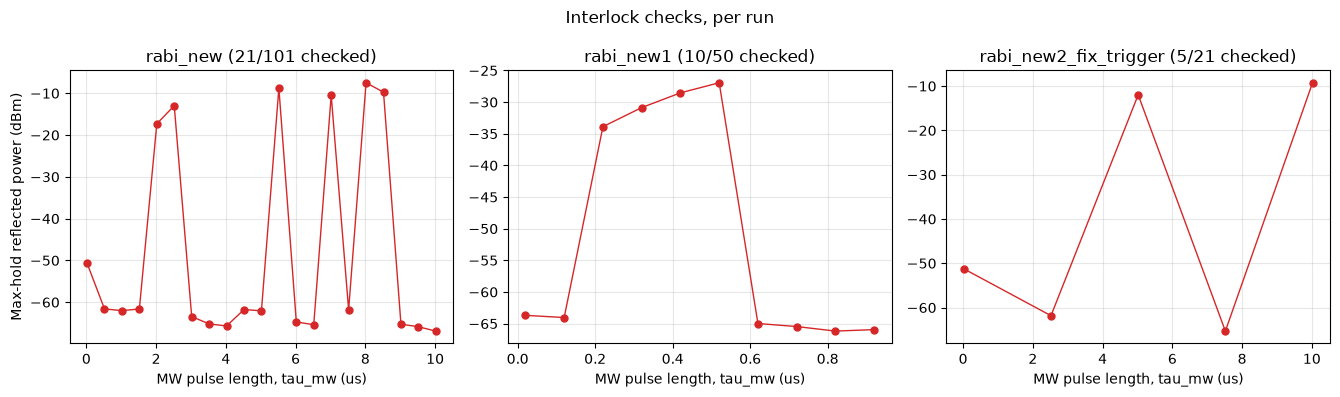

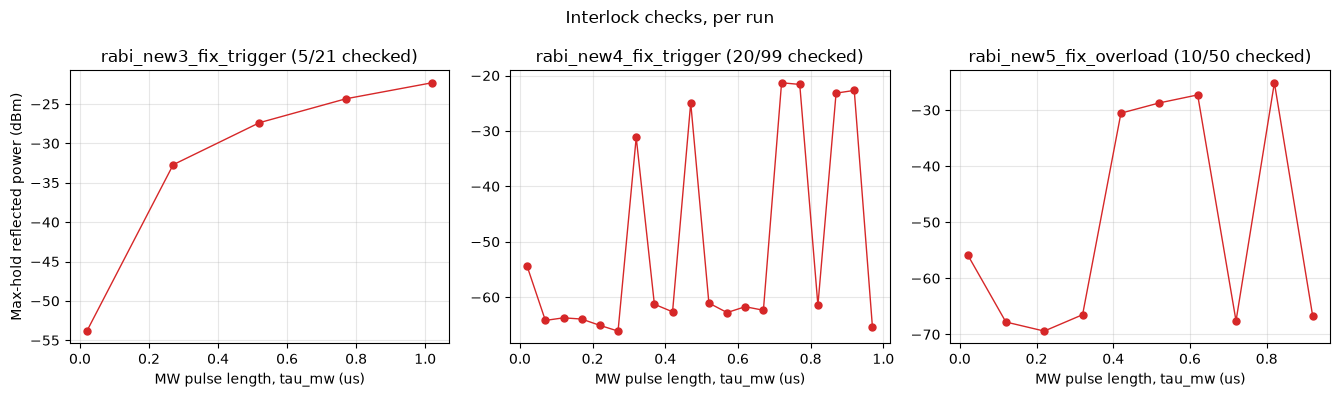

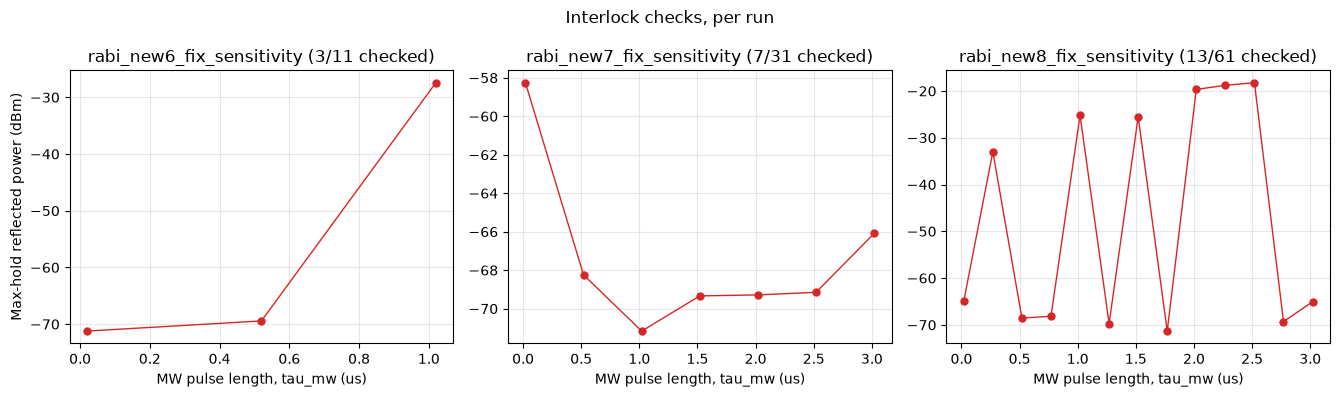

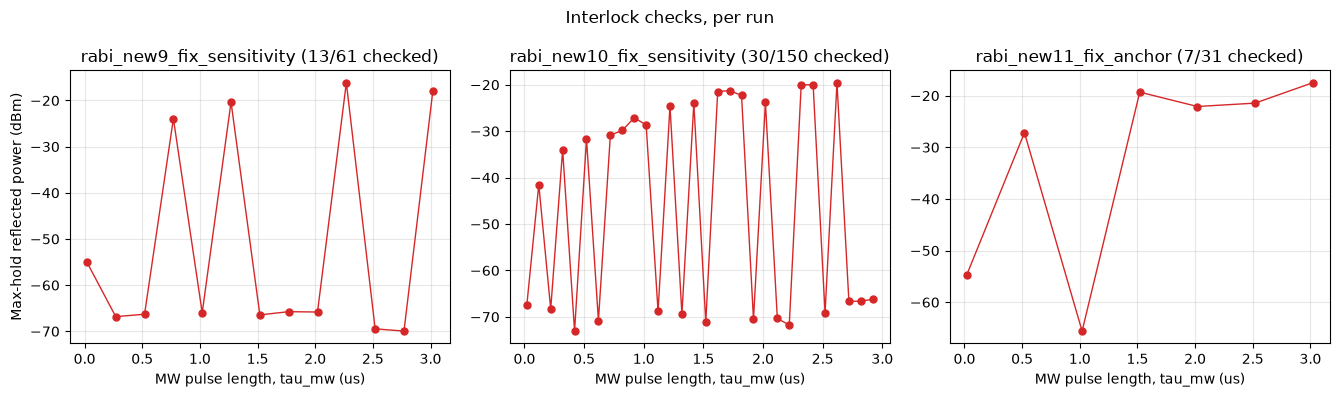

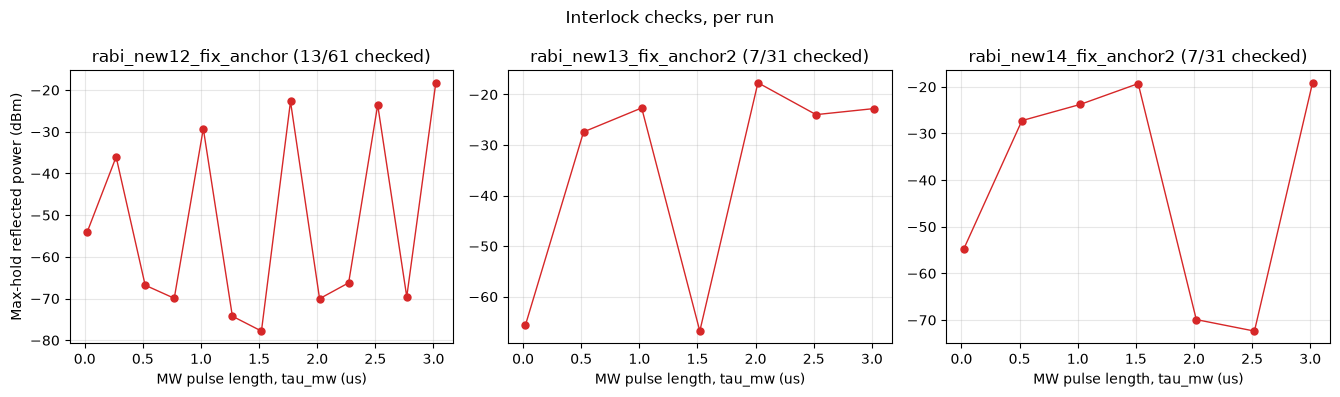

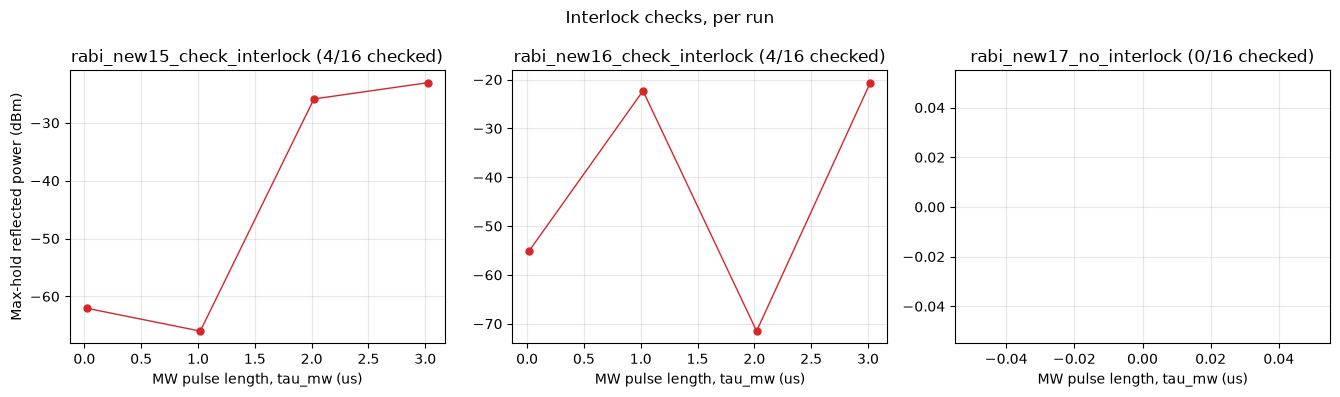

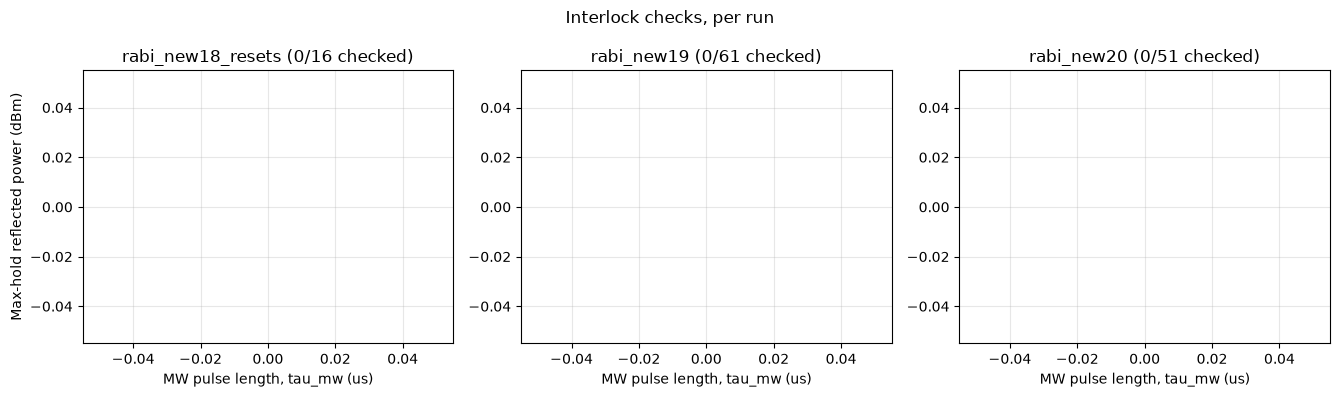

In [4]:
for group in chunked_runs():
    n_runs = len(group)
    fig, axes = plt.subplots(1, n_runs, figsize=(4.5 * n_runs, 4), squeeze=False)
    axes = axes[0]

    for col, (file_name, d) in enumerate(group):
        checked = ~np.isnan(d["reflected_dbm"])
        axes[col].plot(d["mw_us"][checked], d["reflected_dbm"][checked], "o-", ms=5, lw=1, color="tab:red")
        axes[col].set_xlabel("MW pulse length, tau_mw (us)")
        axes[col].set_title(f"{file_name} ({checked.sum()}/{len(d['mw_us'])} checked)")
        axes[col].grid(alpha=0.3)

    axes[0].set_ylabel("Max-hold reflected power (dBm)")
    fig.suptitle("Interlock checks, per run")
    plt.tight_layout()
    plt.show()


## Pre-flight reflected-power sweep, per run

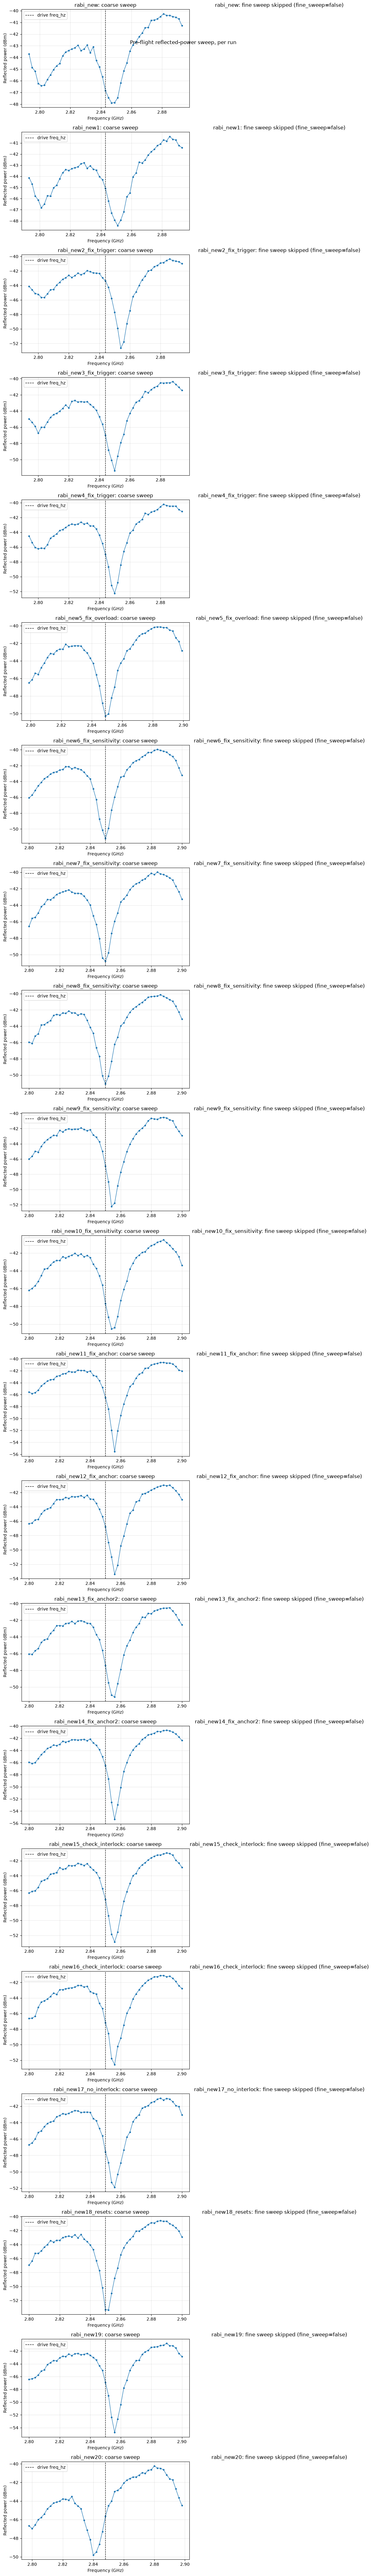

In [5]:
import os

n_runs = len(runs)
fig, axes = plt.subplots(n_runs, 2, figsize=(12, 4 * n_runs), squeeze=False)

for row, (file_name, d) in enumerate(runs.items()):
    coarse_path = f"{d['run_path']}/{file_name}_resonance_coarse.csv"
    fine_path = f"{d['run_path']}/{file_name}_resonance_fine.csv"
    freq_ghz = d["metadata"]["freq_hz"] / 1e9

    if not os.path.exists(coarse_path):
        axes[row, 0].set_title(f"{file_name}: no resonance CSVs found")
        axes[row, 1].set_title(f"{file_name}: no resonance CSVs found")
        print(f"{file_name}: no resonance_coarse.csv found "
              "(reflected_power_scan=false, or an older run predating this feature).")
        continue

    coarse = np.genfromtxt(coarse_path, delimiter=",", names=True)
    axes[row, 0].plot(coarse["frequency_hz"] / 1e9, coarse["power_dbm"], "o-", ms=3, lw=1)
    axes[row, 0].axvline(freq_ghz, color="k", ls="--", lw=1, label="drive freq_hz")
    axes[row, 0].set_xlabel("Frequency (GHz)")
    axes[row, 0].set_ylabel("Reflected power (dBm)")
    axes[row, 0].set_title(f"{file_name}: coarse sweep")
    axes[row, 0].legend()
    axes[row, 0].grid(alpha=0.3)

    if not os.path.exists(fine_path):
        axes[row, 1].set_title(f"{file_name}: fine sweep skipped (fine_sweep=false)")
        axes[row, 1].axis("off")
        continue

    fine = np.genfromtxt(fine_path, delimiter=",", names=True)
    axes[row, 1].plot(fine["frequency_hz"] / 1e9, fine["power_dbm"], "o-", ms=3, lw=1, color="tab:orange")
    axes[row, 1].axvline(freq_ghz, color="k", ls="--", lw=1, label="drive freq_hz")
    axes[row, 1].set_xlabel("Frequency (GHz)")
    axes[row, 1].set_ylabel("Reflected power (dBm)")
    axes[row, 1].set_title(f"{file_name}: fine sweep")
    axes[row, 1].legend()
    axes[row, 1].grid(alpha=0.3)

fig.suptitle("Pre-flight reflected-power sweep, per run")
plt.tight_layout()
plt.show()


## Noise floor: `rabi_off_resonance_fix_long`

Plotted separately from `rabi_new`/`rabi_new1` above -- this run is driven
off the NV resonance (2.27 GHz vs. the real ~2.843 GHz), collected AFTER
the `anchor_free_reps`/trigger fixes, so it's a direct measurement of the
lock-in's noise floor with the background artifact fixed: no real ODMR
signal should be present, so whatever `R` shows here characterizes the
measurement's residual noise floor, not signal.

rabi_off_resonance_fix_long: 101 points, tau_mw 0.020-10.020 us
freq_hz=2270000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=2e-05
phase_deg=0.0



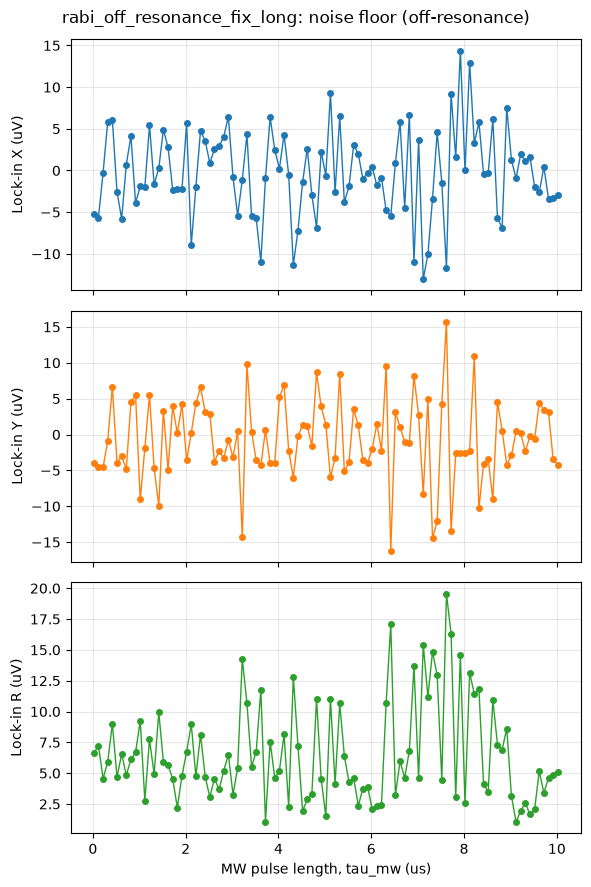

R noise floor: mean=6.546 uV, std=4.004 uV, min=1.034 uV, max=19.560 uV


In [6]:
noise_file_name = "rabi_off_resonance_fix_long"
noise_run_path = f"{DATA_DIR}/{noise_file_name}"

noise_mw_us = np.load(f"{noise_run_path}/{noise_file_name}_rabi_mw_us.npy")
noise_x_v = np.load(f"{noise_run_path}/{noise_file_name}_rabi_x.npy")
noise_y_v = np.load(f"{noise_run_path}/{noise_file_name}_rabi_y.npy")
noise_r_v = np.sqrt(noise_x_v**2 + noise_y_v**2)

with open(f"{noise_run_path}/{noise_file_name}_rabi_metadata.txt") as fh:
    noise_metadata_text = fh.read()
print(f"{noise_file_name}: {len(noise_mw_us)} points, tau_mw "
      f"{noise_mw_us.min():.3f}-{noise_mw_us.max():.3f} us")
print(noise_metadata_text)

fig, axes = plt.subplots(3, 1, figsize=(6, 9), sharex=True)
axes[0].plot(noise_mw_us, noise_x_v * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[1].plot(noise_mw_us, noise_y_v * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[2].plot(noise_mw_us, noise_r_v * 1e6, "o-", ms=4, lw=1, color="tab:green")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("MW pulse length, tau_mw (us)")
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"{noise_file_name}: noise floor (off-resonance)")
plt.tight_layout()
plt.show()

print(f"R noise floor: mean={noise_r_v.mean()*1e6:.3f} uV, "
      f"std={noise_r_v.std()*1e6:.3f} uV, "
      f"min={noise_r_v.min()*1e6:.3f} uV, max={noise_r_v.max()*1e6:.3f} uV")


## Direct comparison: `rabi_new7_fix_sensitivity`, `rabi_new8_fix_sensitivity`, `rabi_new9_fix_sensitivity`, and `rabi_new10_fix_sensitivity`

All three runs plotted on the SAME axes (not side-by-side columns) for direct
overlay comparison.

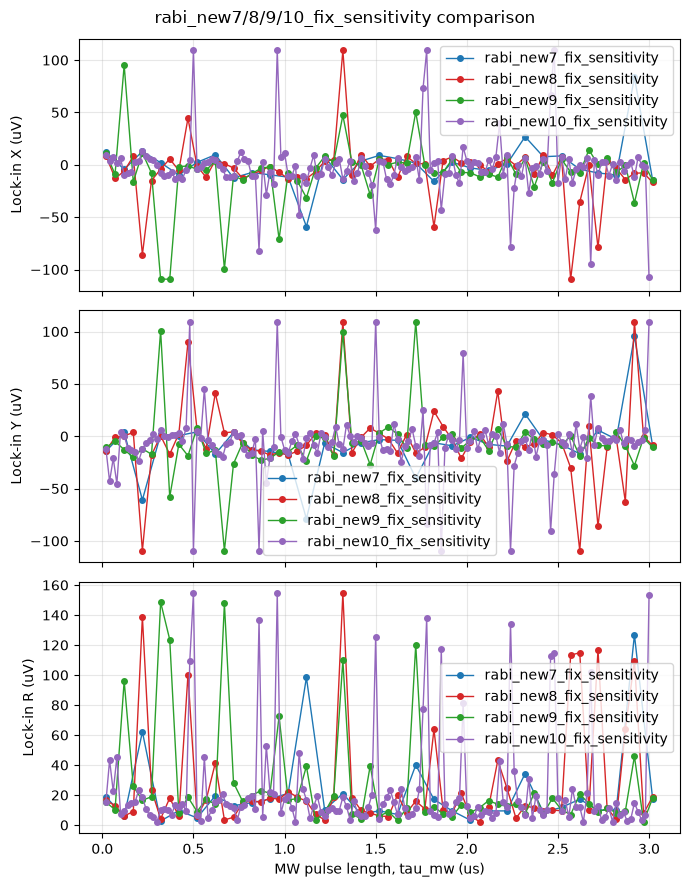

In [7]:
compare_names = ["rabi_new7_fix_sensitivity", "rabi_new8_fix_sensitivity", "rabi_new9_fix_sensitivity", "rabi_new10_fix_sensitivity"]
compare_colors = ["tab:blue", "tab:red", "tab:green", "tab:purple"]

compare_runs = {}
for name in compare_names:
    run_path = f"{DATA_DIR}/{name}"
    mw_us = np.load(f"{run_path}/{name}_rabi_mw_us.npy")
    x_v = np.load(f"{run_path}/{name}_rabi_x.npy")
    y_v = np.load(f"{run_path}/{name}_rabi_y.npy")
    compare_runs[name] = dict(mw_us=mw_us, x_v=x_v, y_v=y_v)

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
for name, color in zip(compare_names, compare_colors):
    d = compare_runs[name]
    r_v = np.sqrt(d["x_v"]**2 + d["y_v"]**2)
    axes[0].plot(d["mw_us"], d["x_v"] * 1e6, "o-", ms=4, lw=1, color=color, label=name)
    axes[1].plot(d["mw_us"], d["y_v"] * 1e6, "o-", ms=4, lw=1, color=color, label=name)
    axes[2].plot(d["mw_us"], r_v * 1e6, "o-", ms=4, lw=1, color=color, label=name)

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("MW pulse length, tau_mw (us)")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("rabi_new7/8/9/10_fix_sensitivity comparison")
plt.tight_layout()
plt.show()


## Direct comparison: `rabi_new18_resets`, `rabi_new19`, `rabi_new20`

`new18`/`new19` are both `resequence_interval=1` (reset every point).
`new20` replaces the earlier `new20_test` (`SOUR1/2:FUNC:ARB:SYNC`
candidate, which turned out NOT to fix the spikes -- see notes.md) -- note
`new20` also differs in `freq_hz` (2.848 GHz) and sweep range
(0.02-10.02 us) from `new18`/`new19` (2.850 GHz, 0.02-3.02 us).

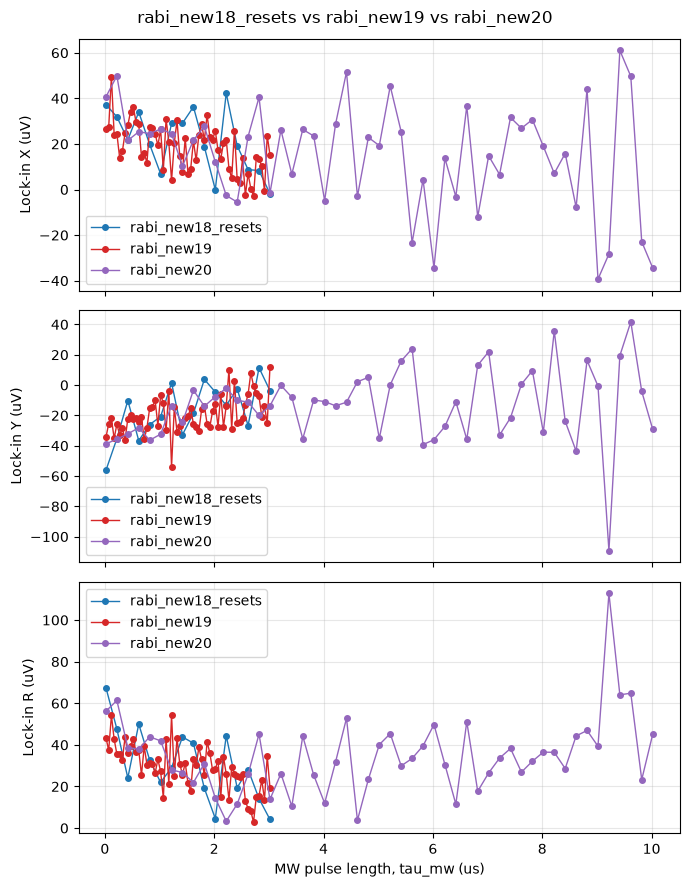

In [8]:
compare_names_1819 = ["rabi_new18_resets", "rabi_new19", "rabi_new20"]
compare_colors_1819 = ["tab:blue", "tab:red", "tab:purple"]

compare_runs_1819 = {}
for name in compare_names_1819:
    run_path = f"{DATA_DIR}/{name}"
    mw_us = np.load(f"{run_path}/{name}_rabi_mw_us.npy")
    x_v = np.load(f"{run_path}/{name}_rabi_x.npy")
    y_v = np.load(f"{run_path}/{name}_rabi_y.npy")
    compare_runs_1819[name] = dict(mw_us=mw_us, x_v=x_v, y_v=y_v)

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
for name, color in zip(compare_names_1819, compare_colors_1819):
    d = compare_runs_1819[name]
    r_v = np.sqrt(d["x_v"]**2 + d["y_v"]**2)
    axes[0].plot(d["mw_us"], d["x_v"] * 1e6, "o-", ms=4, lw=1, color=color, label=name)
    axes[1].plot(d["mw_us"], d["y_v"] * 1e6, "o-", ms=4, lw=1, color=color, label=name)
    axes[2].plot(d["mw_us"], r_v * 1e6, "o-", ms=4, lw=1, color=color, label=name)

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("MW pulse length, tau_mw (us)")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("rabi_new18_resets vs rabi_new19 vs rabi_new20")
plt.tight_layout()
plt.show()
